In [1]:
import arviz as az
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax.scipy.special import gammaln, logsumexp
from numpyro.infer import NUTS, MCMC, Predictive, SVI
import jax.scipy.special as jsp
import jax.scipy.stats as jsstats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_fontja
import pickle

from numpyro.infer import SVI, Trace_ELBO, TraceGraph_ELBO
from numpyro.infer.autoguide import AutoDelta, AutoMultivariateNormal, AutoBNAFNormal# AutoBNAFNormal

In [2]:
def nb2_logsf_normal(cap_t, mu_t, alpha):
    var_t = mu_t + (mu_t**2) / alpha
    sigma_t = jnp.sqrt(var_t)
    return jsstats.norm.logsf(cap_t - 0.5, loc=mu_t, scale=sigma_t)


def bass_model(
    t_values,
    season_indices,
    inventory_cap,
    sales_data=None,
    season_dim=12,
    K=6,
    C0=0,
    **params,
):
    T_len = len(t_values)
    M = numpyro.sample("M", dist.LogNormal(params['M_mu'], params['M_var']))
    
    log_p = numpyro.sample("log_p", dist.Normal(params['log_p_mu'], params['log_p_var']))
    log_q = numpyro.sample("log_q", dist.Normal(params['log_q_mu'], params['log_q_var']))
    
#    p = numpyro.deterministic("p", jnp.exp(log_p))
    p_base = numpyro.deterministic("p_base", jnp.exp(log_p))
    q = numpyro.deterministic("q", jnp.exp(log_q))

    alpha = numpyro.sample("alpha", dist.Exponential(params['alpha_var']))
       
    # 係数 a, b をサンプリング (中心0の正規分布)
    # これにより、季節成分 S(t) の期待値は 0 になります
    season_amp = numpyro.sample("season_amp", dist.HalfNormal(params["season_amp_scale"]))
    a_raw = numpyro.sample("fourier_a_raw", dist.Normal(0.0, 1), sample_shape=(K,))
    b_raw = numpyro.sample("fourier_b_raw", dist.Normal(0.0, 1), sample_shape=(K,))

    # 高周波成分を削り，　オーバーフィットを避ける
    decay = params.get("fourier_decay", 1.0)
    k_idx = jnp.arange(1, K + 1, dtype=t_values.dtype)
    scale_k = 1.0 / (k_idx ** decay)

    a = numpyro.deterministic("fourier_a", season_amp * a_raw * scale_k)
    b = numpyro.deterministic("fourier_b", season_amp * b_raw * scale_k)

    m_grid = jnp.arange(season_dim, dtype=t_values.dtype)
    angs = 2.0 * jnp.pi * jnp.outer(m_grid, k_idx) / season_dim  # (season_dim, K)

    raw = jnp.sum(a * jnp.cos(angs) + b * jnp.sin(angs), axis=1)  # (season_dim,)
    raw_centered = raw - jnp.mean(raw)

    # expで正値化 → 平均1に正規化（スケール交絡を抑える）
    season_factors = jnp.exp(raw_centered)
    season_factors = season_factors / jnp.mean(season_factors)
    numpyro.deterministic("season_factors", season_factors)

    # --- 広告効果（Boost）を p に作用させる ---
    # ブースト期間中は p が (1 + boost) 倍になると仮定
    # あるいは単に p_boost を加算する形でもOKです
    log_boost_strength = numpyro.sample("log_boost_strength", dist.Normal(params['boost_mu'], params["boost_scale"]))
    boost_strength = numpyro.deterministic("boost_strength", jnp.exp(log_boost_strength))
    # numpyro.sample("boost_strength", dist.HalfNormal(params['boost_scale']))
    
    # 時系列ごとの p(t) を作成
    is_boost_period = (t_values < params['boost_period']).astype(jnp.float32)
    
    # p_t: 広告期間中はイノベーション係数が高まる
    # (例: 広告により「認知」が広がる = 外部影響 p が強まる)
    p_t = numpyro.deterministic("p_t", p_base + boost_strength * is_boost_period)

    season_idx = jnp.asarray(season_indices).astype(jnp.int32)
    
    def transition_fn(carry, t_idx):
        cumulative_adopters = carry
        remaining_market = jnp.maximum(M - cumulative_adopters, 0.0)
    
        # tracer-safe な取り出し
        s_i = jax.lax.dynamic_index_in_dim(season_idx, t_idx, axis=0, keepdims=False)
        s_t = season_factors[s_i]
    
        adoption_rate = p_t[t_idx] + q * (cumulative_adopters / jnp.maximum(M, 1e-9))
    
        lam = jnp.maximum(s_t * adoption_rate, 0.0)
        new_adopters = remaining_market * (1.0 - jnp.exp(-lam))   #  dt=1 想定
    
        new_cumulative = cumulative_adopters + new_adopters
        return new_cumulative, new_adopters

    init_cumulative = jnp.asarray(C0, dtype=jnp.float32)
    time_indices = jnp.arange(T_len, dtype=jnp.int32)
    _, bass_flow = jax.lax.scan(transition_fn, init_cumulative, time_indices)    
#    init_cumulative = 0.0
#    time_indices = jnp.arange(T_len, dtype=jnp.int32)
#    _, bass_flow = jax.lax.scan(transition_fn, init_cumulative, time_indices)
    
    mu_t = jnp.clip(bass_flow, a_min=1e-9)

    # --- 季節性と最終調整 ---
    # bass_flow は M に収まるように計算されている
    # ここに季節性を掛ける
    mu_raw = bass_flow # * season_factors[season_indices]
    mu_t = jnp.clip(mu_raw, a_min=1e-9)
    
    numpyro.deterministic("demand_pred", mu_t)
    
    sales_mean = jnp.minimum(mu_t, inventory_cap)
    numpyro.deterministic("sales_mean", sales_mean)

    if sales_data is not None:
        y = jnp.asarray(sales_data).astype(jnp.int32)

        nb = dist.NegativeBinomial2(mean=mu_t, concentration=alpha)

        # 打ち切り判定（capが時系列）
        is_censored = y >= inventory_cap

        # 非打ち切り：通常のNB2
        logp_obs = nb.log_prob(y)

        # 打ち切り：log P(Y >= cap_t) を正規近似
        logp_cens = nb2_logsf_normal(inventory_cap, mu_t, alpha)

        pointwise_log_lik = jnp.where(is_censored, logp_cens, logp_obs)        
        numpyro.deterministic("log_likelihood", pointwise_log_lik)
        numpyro.factor("obs_loglik", jnp.sum(pointwise_log_lik))    


def meta_model(t_values, season_indices, inventory_cap, sales_data, **init_params):   
    M_mu_optim = numpyro.param("M_mu_opt", init_params["M_mu"]) 
    M_var_optim = numpyro.param("M_var_opt", init_params["M_var"], constraint=dist.constraints.positive)
    
    log_p_mu_optim = numpyro.param("log_p_mu_opt", init_params["log_p_mu"])
    log_p_var_optim = numpyro.param("log_p_var_opt", init_params["log_p_var"], constraint=dist.constraints.positive)
    
    log_q_mu_optim = numpyro.param("log_q_mu_opt", init_params["log_q_mu"])
    log_q_var_optim = numpyro.param("log_q_var_opt", init_params["log_q_var"], constraint=dist.constraints.positive)
    
    alpha_var_optim = numpyro.param("alpha_var_opt", init_params["alpha_var"], constraint=dist.constraints.positive)

    season_amp_scale = numpyro.param("season_amp_scale_opt", init_params["season_amp_scale"], constraint=dist.constraints.positive)
    boost_mu = numpyro.param("boost_mu_opt", init_params["boost_mu"])
    boost_scale = numpyro.param("boost_scale_opt", init_params["boost_scale"], constraint=dist.constraints.positive)    
    # season_sigma_optim = numpyro.param("season_sigma_opt", init_params["season_sigma"], constraint=dist.constraints.positive)

    # 辞書にまとめて元のモデルに渡す
    learned_params = {
        'M_mu': M_mu_optim, # init_params["M_mu"], # , マーケットパラメータは学習させていない
        'M_var': init_params["M_var"], # , マーケットパラメータは学習させていない
        'log_p_mu': log_p_mu_optim, # log_p_mu_optim, 
        'log_p_var': log_p_var_optim, 
        'log_q_mu': log_q_mu_optim, # qは学習させない
        'log_q_var': log_q_var_optim, # qは学習させない
        'alpha_var': alpha_var_optim,
        "season_amp_scale": season_amp_scale,
        "boost_mu": boost_mu, 
        "boost_scale": boost_scale,
        "boost_period": init_params["boost_period"]
    }
    
    # 元のモデルを呼び出す
    bass_model(
        t_values, 
        season_indices, 
        inventory_cap, 
        sales_data, 
        **learned_params
    )

In [3]:
prior_params = {
    "M_mu": jnp.log(20_000), 
    "M_var": 0.8,
    "log_p_mu": jnp.log(0.001),
    "log_p_var": 0.01,
    "log_q_mu": jnp.log(0.025),
    "log_q_var": 0.5,
    "alpha_var": 0.5,
    "season_amp_scale": 1,
    "boost_period": 5,
    "boost_mu": jnp.log(0.001),
    "boost_scale": 0.005,
}

In [4]:
prior_params = {
    "M_mu": jnp.log(5000), 
    "M_var": 0.5,
    "log_p_mu": jnp.log(0.01),
    "log_p_var": 0.3,
    "log_q_mu": jnp.log(0.025),
    "log_q_var": 0.5,
    "alpha_var": 0.5,
    "season_amp_scale": 1,
    "boost_period": 0,
    "boost_mu": jnp.log(0.001),
    "boost_scale": 0.1,
}
# jnp.log(0.001)

## データの読み込み

In [5]:
df = pd.read_csv("data/20251101coolrevolution実績.csv", parse_dates=["受注_伝票登録日付"])
df = df.rename(columns={"受注_伝票登録日付": "date", "売上金額": "sales"})
df["day"] = df.date.dt.date
sales = df.groupby(pd.Grouper(key='date', freq='MS'))["請求済数量"].sum()
inventory_cap = pd.read_csv("data/クーレボ在庫.csv")
inventory_cap.yyyymm = inventory_cap.yyyymm.map(lambda x: pd.to_datetime(str(x)+"01"))
inventory_cap = inventory_cap.rename(columns={"yyyymm": "date", '在庫数（月末時点）': 'inventory'})
inventory_cap = inventory_cap.set_index('date')["inventory"]

data = pd.DataFrame({"sales": sales, "inventory": inventory_cap}).dropna(axis=0, how='any')
# data = data.reindex(index=pd.date_range("2019-10-01", '2025-06-01', freq='MS'))
data['month'] = data.index.month

# 在庫キャップ
data['inventory_cap'] = data[['inventory', 'sales']].max(axis=1)
data = data.fillna(0)
data = data.reset_index()

t_values = data.index
inv_cap = data['inventory_cap']
season_indices = data['month'] - 1
sales = data['sales']

## 設定している事前分布の確認
- とくにM, p, q は確認する必要あり
- M に関してはパラメータを学習させず自分たちの知見で決めた方がよさそう

In [6]:
# 事前分布からのサンプリング
predictive = Predictive(bass_model, num_samples=10000)
rng_key = jax.random.PRNGKey(42)
prior_samples = predictive(
    rng_key, 
    t_values=t_values.values, 
    season_indices=season_indices.values, 
    inventory_cap=inv_cap.values,
    sales_data=None, 
    **prior_params
)

/Users/tsuyos-u/Library/Caches/pypoetry/virtualenvs/semi-bayes-tseries-wVQtb5VF-py3.11/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:5958: UserWarning: Explicitly requested dtype int64 requested in arange is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return _arange(start, stop=stop, step=step, dtype=dtype,


<Axes: ylabel='Frequency'>

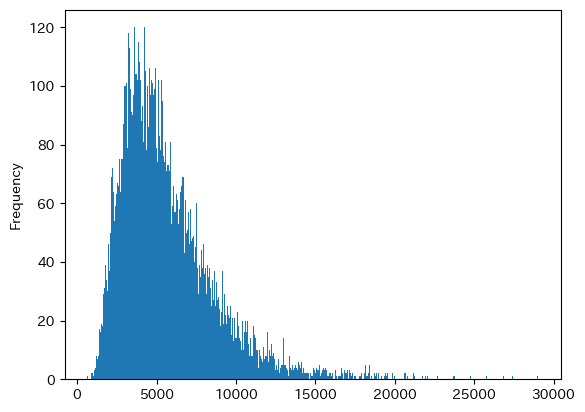

In [7]:
pd.Series(prior_samples['M']).plot(kind='hist', bins=500)

<Axes: ylabel='Frequency'>

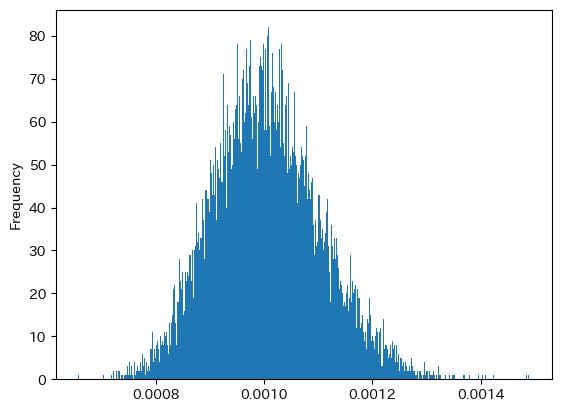

In [8]:
pd.Series(prior_samples['boost_strength']).plot(kind='hist', bins=500)

<Axes: ylabel='Frequency'>

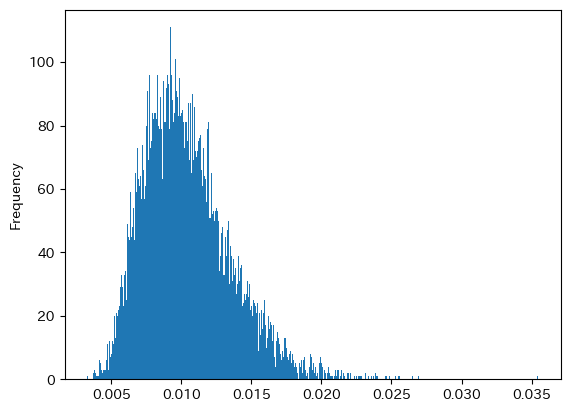

In [9]:
pd.Series(prior_samples['p_base']).plot(kind='hist', bins=500)

## ハイパーパラメータの最適化
- 事前分布のパラメータをStochastic Variational Inference で調整

In [10]:
optimizer = numpyro.optim.Adam(step_size=1e-3)
guide = AutoMultivariateNormal(meta_model)
svi = SVI(meta_model, guide, optimizer, loss=Trace_ELBO(num_particles=1))

# svi = SVI(meta_model, guide, optimizer, loss=Trace_ELBO())

# 3. 実行（ハイパーパラメータの最適化）
svi_result = svi.run(
    jax.random.PRNGKey(0), 200_000, 
    t_values=t_values.values, 
    season_indices=season_indices.values, 
    inventory_cap=inv_cap.values, 
    sales_data=sales.values,
    **prior_params
)

params = dict()
for k, v in prior_params.items():
    try:
        params[k] = svi_result.params[f"{k}_opt"]
    except:
        params[k] = prior_params[k]
        pass

display(params)

/Users/tsuyos-u/Library/Caches/pypoetry/virtualenvs/semi-bayes-tseries-wVQtb5VF-py3.11/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:5958: UserWarning: Explicitly requested dtype int64 requested in arange is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return _arange(start, stop=stop, step=step, dtype=dtype,
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200000/200000 [00:27<00:00, 7160.23it/s, init loss: 1536874905600.0000, avg. loss [190001-200000]: 197.1030]


{'M_mu': Array(8.763139, dtype=float32),
 'M_var': Array(0.5, dtype=float32),
 'log_p_mu': Array(-5.7335224, dtype=float32),
 'log_p_var': Array(0.06718177, dtype=float32),
 'log_q_mu': Array(-6.0995526, dtype=float32),
 'log_q_var': Array(0.15023033, dtype=float32),
 'alpha_var': Array(0.8678309, dtype=float32),
 'season_amp_scale': Array(0.8201915, dtype=float32),
 'boost_period': 0,
 'boost_mu': Array(-2.459969, dtype=float32),
 'boost_scale': Array(1.1653204, dtype=float32)}

## サンプリング
- サンプリングが異常に遅い場合は，初期パラメータの設定の異常と思わえる．すぐに停止して，パラメータを振り直した方がよい

In [11]:
# init_params = guide.median(svi_result.params)
# svi.guide()

In [12]:
seed_mcmc = 125
nuts = NUTS(bass_model, dense_mass=True)
mcmc = MCMC(nuts, num_warmup=1000, num_samples=10000, num_chains=1, progress_bar=True)

mcmc.run(
    jax.random.PRNGKey(seed_mcmc),
    t_values.values,
    season_indices.values,
    inv_cap.values,
    sales.values,
    season_dim=12,
#    init_params=init_params, 
    K=5, 
    **params
)

sample: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11000/11000 [00:05<00:00, 1843.96it/s, 7 steps of size 4.22e-01. acc. prob=0.91]


## WAICの計算
- WAICは低いほどよい
- サンプリングを使っているので，何回かシードをサンプリングし直してみてスコアを見る

In [13]:
idata = az.from_numpyro(mcmc)

# scale="deviance" -> 小さいほど良い（Optunaのminimizeと合う）
waic_result = az.waic(idata, scale="deviance")            
waic_score = waic_result.elpd_waic

# WAICが小さいほど予測はよい
print(waic_score)

380.6819362640381


/Users/tsuyos-u/Library/Caches/pypoetry/virtualenvs/semi-bayes-tseries-wVQtb5VF-py3.11/lib/python3.11/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/tsuyos-u/Library/Caches/pypoetry/virtualenvs/semi-bayes-tseries-wVQtb5VF-py3.11/lib/python3.11/site-packages/arviz/stats/stats.py:1695: UserWarning: The point-wise WAIC is the same with the sum WAIC, please double check
            the Observed RV in your model to make sure it returns element-wise logp.
            
  warnings.warn(


In [17]:
with open("results/normal/posterior.pickle", mode='wb') as f:
    pickle.dump(mcmc.get_samples(), f)

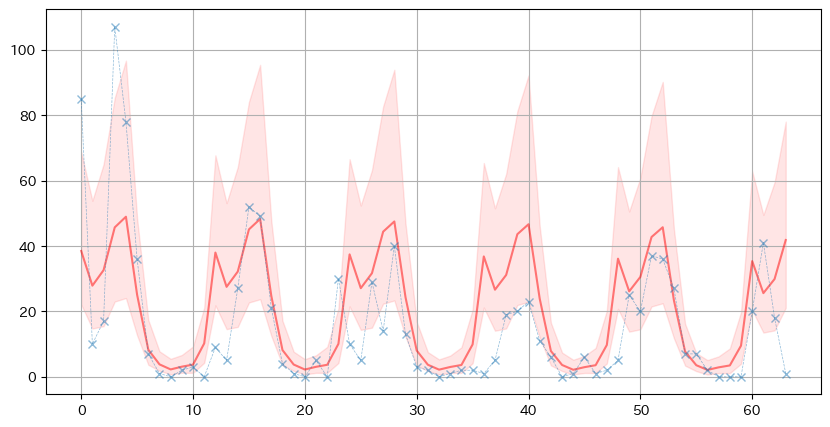

In [18]:
#  潜在需要
fig, ax = plt.subplots(1, figsize=(10, 5))
ax.plot(pd.DataFrame(mcmc.get_samples()['demand_pred']).mean(), color="red", alpha=0.5)
ax.fill_between(
    pd.DataFrame(mcmc.get_samples()['demand_pred']).columns,
    pd.DataFrame(mcmc.get_samples()['demand_pred']).quantile(0.025), 
    pd.DataFrame(mcmc.get_samples()['demand_pred']).quantile(0.975),
    color="red", alpha=0.1)
ax.plot(sales, marker='x', linewidth=0.5, markersize=6, linestyle='--', alpha=0.5)
ax.grid()

In [19]:
# pickle.dumpmcmc.get_samples()
# fig, ax = plt.subplots(3, figsize=(10, 5))
# pd.Series(mcmc.get_samples()["M"]).plot(kind='hist', bins=200, ax=ax[0])
# pd.Series(mcmc.get_samples()["p_t"][:, -1]).plot(kind='hist', bins=200, ax=ax[1])
# pd.Series(mcmc.get_samples()["q"]).plot(kind='hist', bins=200, ax=ax[2])

In [20]:
pd.Series((1- (1 - np.exp(mcmc.get_samples()['log_q']))**12)).mean()

np.float32(0.026882717)

In [21]:
pd.Series((1- (1 - np.exp(mcmc.get_samples()['log_p']))**12)).mean()

np.float32(0.038166977)

In [22]:
jnp.exp(mcmc.get_samples()['log_p'])

Array([0.00306651, 0.00294259, 0.00321006, ..., 0.00349969, 0.00304954,
       0.00342911], dtype=float32)

<Axes: ylabel='Frequency'>

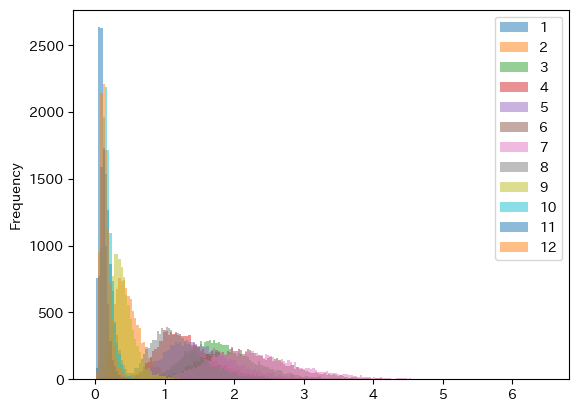

In [23]:
season_factors = pd.DataFrame(mcmc.get_samples()['season_factors'], columns=range(1, 13))
season_factors.plot(kind='hist', bins=200, alpha=0.5)

<Axes: ylabel='Frequency'>

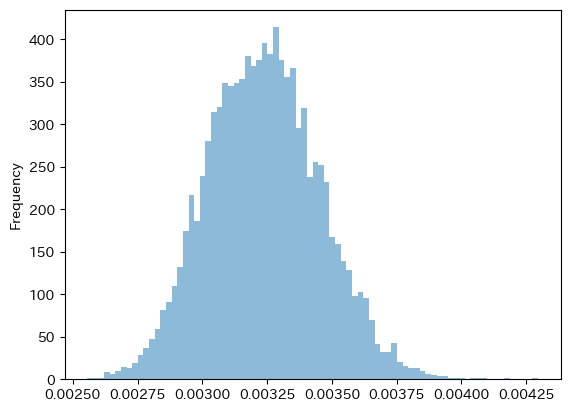

In [24]:
pd.Series(np.exp(mcmc.get_samples()['log_p'])).plot(kind='hist', bins=80, alpha=0.5)

In [25]:
pd.Series(np.exp(mcmc.get_samples()['log_q'])).median() * 12

# 1 - (1 - 0.0025)**12
# ベイズ推定のメリット
# 0.0019 * 12

np.float32(0.026959095)

In [26]:
# 将来についての予測

In [27]:
predictive = Predictive(
    bass_model,
    posterior_samples=mcmc.get_samples(),
    return_sites=["demand_pred", "sales_mean"]
)

In [28]:
dates = pd.date_range("2020-03-01", "2028-03", freq="MS")
new_data = pd.DataFrame(dict(dates=dates, month=dates.month-1))
new_data = new_data.assign(inv_cap=1000)
new_data = new_data.reset_index()
t_values = new_data["index"].values
inv_cap = new_data["inv_cap"].values
season_indices = new_data["month"]

In [29]:
pred = predictive(
    jax.random.PRNGKey(0),
    t_values=t_values,
    season_indices=season_indices,
    inventory_cap=inv_cap,
    sales_data=None,      # 未来は観測なし
    season_dim=12,
    K=5,
    C0=sales.sum(),
    **params              # learned_params を含む
)

/Users/tsuyos-u/Library/Caches/pypoetry/virtualenvs/semi-bayes-tseries-wVQtb5VF-py3.11/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:5958: UserWarning: Explicitly requested dtype int64 requested in arange is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return _arange(start, stop=stop, step=step, dtype=dtype,


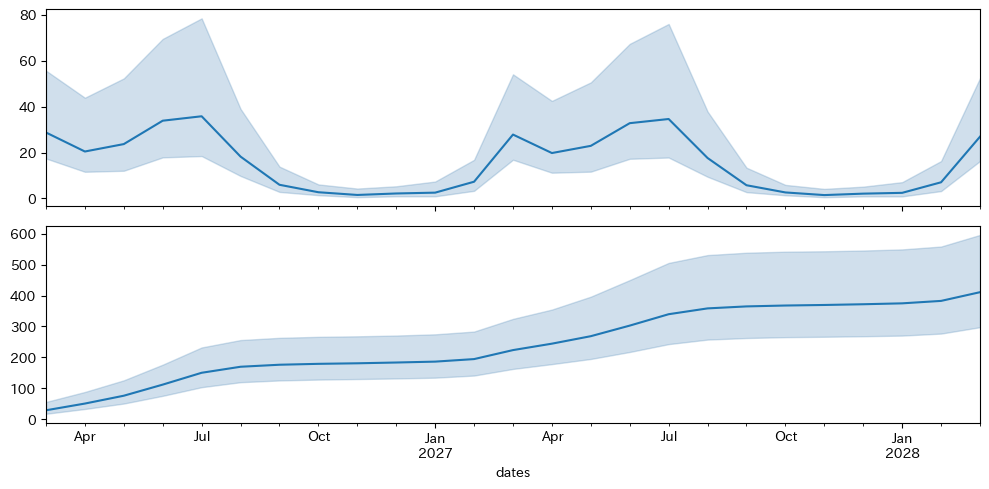

In [39]:
demand_pred = pd.DataFrame(pred['demand_pred']).T
demand_pred.index = dates
demand_pred.index.name = "dates"
demand_pred.to_csv("results/normal/demand_pred.csv")

m = demand_pred["2026-03":].median(axis=1)
upper = demand_pred["2026-03":].quantile(0.975, axis=1)
lower = demand_pred["2026-03":].quantile(0.025, axis=1)

cumsum_m = demand_pred["2026-03":].cumsum(axis=0).median(axis=1)
cumsum_upper = demand_pred["2026-03":].cumsum(axis=0).quantile(0.975, axis=1)
cumsum_lower = demand_pred["2026-03":].cumsum(axis=0).quantile(0.025, axis=1)

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
m.plot(ax=ax[0])
ax[0].fill_between(lower.index, lower, upper, alpha=0.25, color='steelblue')

cumsum_m.plot(ax=ax[1])
ax[1].fill_between(cumsum_lower.index, cumsum_lower, cumsum_upper, alpha=0.25, color='steelblue')
plt.tight_layout()

In [40]:
# demand_pred.median(axis=1)["2026-03":].plot()
# demand_pred["2026-03":].cumsum(axis=0).quantile(0.025, axis=1).plot()
# demand_pred["2026-03":].cumsum(axis=0).quantile(0.975, axis=1).plot()

<Axes: >

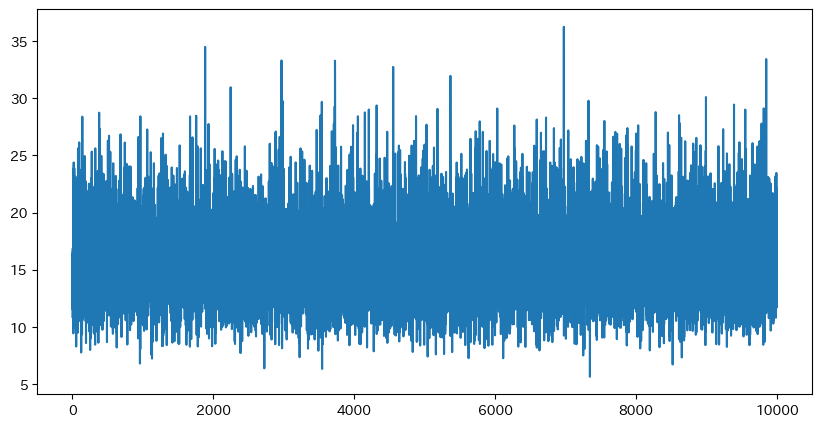

In [41]:
fig, ax = plt.subplots(1, figsize=(10, 5))
demand_pred.median().plot(ax=ax)
# ax.fill_between(t_values,demand_pred.quantile(0.025),  demand_pred.quantile(0.975), alpha=0.25)
# ax.grid()
# ax.set_xticks([d for d in range(len(dates))])
# _ = ax.set_xticklabels([f"{d:%Y-%m-%d}" for d in dates], rotation=60)

In [42]:
# pd.DataFrame(pred['demand_pred']).median().cumsum()

In [43]:
# pd.Timestamp.strtime("YYYYmmdd", dates[0])
# pd.to_numeric()
# dates

In [44]:
# pd.Series(np.log(mcmc.get_samples()["M"])).mean()
# mcmc.get_samples()["M"].mean()

In [ ]:
# 普及カーブ

In [ ]:
# np.exp(mcmc.get_samples()['log_p']).mean()

In [ ]:
# 現在の最大値: 379.2951354980469
# 368.52830600738525
# 368.9754810333252
# 365.59717750549316

In [ ]:
# peak 時刻